In [1]:
!pip install tensorflow opencv-python matplotlib seaborn pandas scikit-learn

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [6]:
import zipfile

with zipfile.ZipFile("archive (2).zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [7]:
dataset_path = "/content/dataset/PlantVillage"

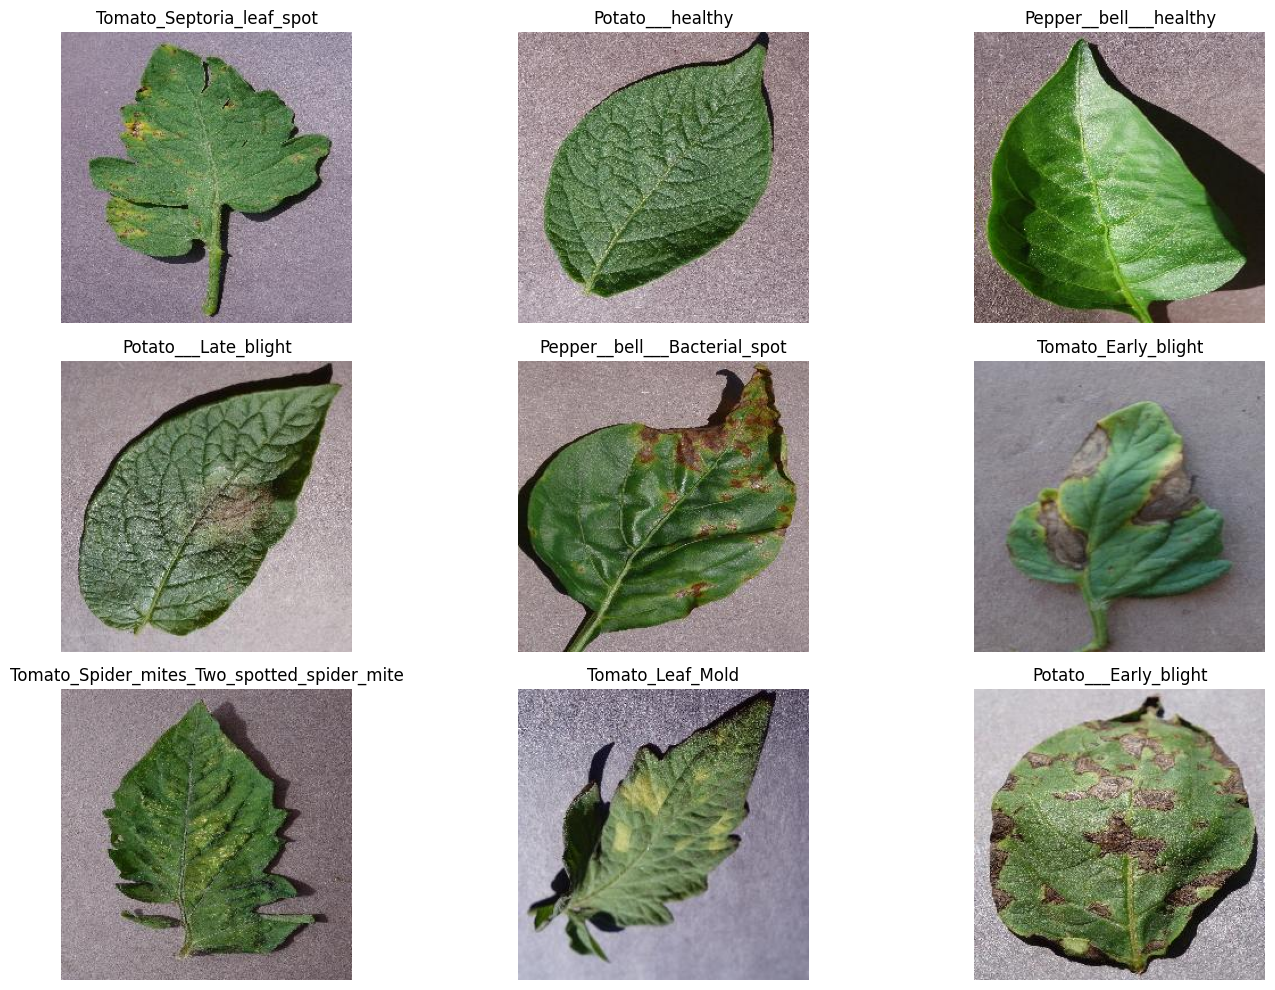

In [8]:
import random
import matplotlib.pyplot as plt

classes = os.listdir(dataset_path)

plt.figure(figsize=(15,10))

for i, disease in enumerate(classes[:9]):

    folder = os.path.join(dataset_path, disease)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = plt.imread(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import cv2
import numpy as np

heights = []
widths = []

for disease in classes:

    folder = os.path.join(dataset_path, disease)

    for img_name in os.listdir(folder)[:20]:

        img = cv2.imread(
            os.path.join(folder, img_name)
        )

        if img is not None:

            heights.append(img.shape[0])
            widths.append(img.shape[1])

print("Average Height:", np.mean(heights))
print("Average Width:", np.mean(widths))

Average Height: 256.0
Average Width: 256.0


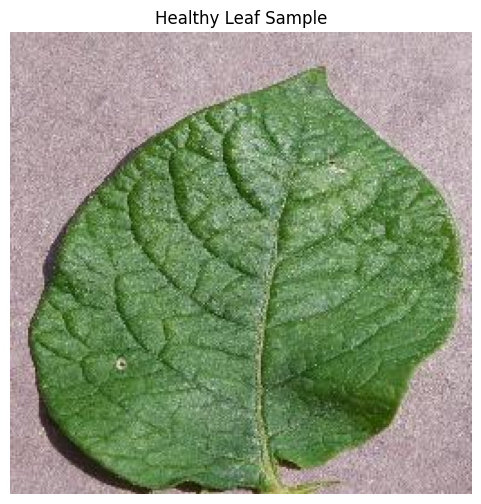

In [10]:
healthy_class = [c for c in classes if "healthy" in c.lower()][0]

healthy_img = random.choice(
    os.listdir(
        os.path.join(dataset_path, healthy_class)
    )
)

healthy_path = os.path.join(
    dataset_path,
    healthy_class,
    healthy_img
)

healthy = plt.imread(healthy_path)

plt.figure(figsize=(6,6))
plt.imshow(healthy)
plt.title("Healthy Leaf Sample")
plt.axis("off")
plt.show()

In [7]:
dataset_path = "/content/dataset/PlantVillage"

In [9]:
# ==========================================
# WEEK 1 - IMAGE PREPROCESSING
# ==========================================

import os
import cv2
import numpy as np

# Use 128 instead of 224 to reduce RAM usage
IMG_SIZE = 128

images = []
labels = []

print("Starting image loading process...")

for disease in os.listdir(dataset_path):

    disease_folder = os.path.join(dataset_path, disease)

    if os.path.isdir(disease_folder):

        count = 0

        for img_name in os.listdir(disease_folder):

            img_path = os.path.join(disease_folder, img_name)

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalize image
                img = img.astype("float32") / 255.0

                images.append(img)
                labels.append(disease)

                count += 1

        print(f"Loaded {count} images from class: {disease}")

print("\nConverting images to NumPy array...")

images = np.array(images, dtype="float32")

print("\nDataset Loaded Successfully!")
print("Total Images:", len(images))
print("Total Labels:", len(labels))
print("Total Classes:", len(set(labels)))

print("\nClass Names:")
print(sorted(list(set(labels))))

Starting image loading process...
Loaded 1771 images from class: Tomato_Septoria_leaf_spot
Loaded 152 images from class: Potato___healthy
Loaded 1478 images from class: Pepper__bell___healthy
Loaded 1000 images from class: Potato___Late_blight
Loaded 997 images from class: Pepper__bell___Bacterial_spot
Loaded 1000 images from class: Tomato_Early_blight
Loaded 1676 images from class: Tomato_Spider_mites_Two_spotted_spider_mite
Loaded 952 images from class: Tomato_Leaf_Mold
Loaded 1000 images from class: Potato___Early_blight
Loaded 1404 images from class: Tomato__Target_Spot
Loaded 373 images from class: Tomato__Tomato_mosaic_virus
Loaded 1909 images from class: Tomato_Late_blight
Loaded 3208 images from class: Tomato__Tomato_YellowLeaf__Curl_Virus
Loaded 1591 images from class: Tomato_healthy
Loaded 2127 images from class: Tomato_Bacterial_spot

Converting images to NumPy array...

Dataset Loaded Successfully!
Total Images: 20638
Total Labels: 20638
Total Classes: 15

Class Names:
['Pe

In [10]:
print("Total Images:", len(images))
print("Total Classes:", len(set(labels)))

Total Images: 20638
Total Classes: 15


In [11]:
print(dataset_path)

/content/dataset/PlantVillage
